# 01 - EDA et preprocessing

Projet: **Maintenance predictive industrielle**  
Objectif principal: predire `failure_within_24h`, c'est-à-dire identifier les machines susceptibles de tomber en panne dans les 24 prochaines heures.

Ce notebook couvre:
- compréhension du dataset,
- qualité des données,
- traitement des valeurs manquantes,
- analyse de la cible,
- analyse des variables capteurs,
- création d'un `health_score`,
- split train/test chronologique,
- sauvegarde de `data/processed/cleaned_data.csv`.

## 1. Imports et configuration

In [84]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="Set2")

PROJECT_ROOT = Path("..").resolve()
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "predictive_maintenance_v3.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_data.csv"

## 2. Chargement du dataset

In [85]:
df = pd.read_csv(RAW_DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [86]:
print(f"Nombre de lignes: {df.shape[0]:,}".replace(",", " "))
print(f"Nombre de colonnes: {df.shape[1]}")
df.info()

Nombre de lignes: 24 042
Nombre de colonnes: 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                24042 non-null  datetime64[ns]
 1   machine_id               24042 non-null  int64         
 2   machine_type             24042 non-null  object        
 3   vibration_rms            23042 non-null  float64       
 4   temperature_motor        23208 non-null  float64       
 5   current_phase_avg        23311 non-null  float64       
 6   pressure_level           23118 non-null  float64       
 7   rpm                      23509 non-null  float64       
 8   operating_mode           24042 non-null  object        
 9   hours_since_maintenance  24042 non-null  float64       
 10  ambient_temp             24042 non-null  float64       
 11  rul_hours                24042 non-null  floa

In [87]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,24042,NaN,NaN,NaN,2024-01-08 00:06:30.111721216,2024-01-01 00:00:00,2024-01-04 12:24:13.750000128,2024-01-08 00:11:30,2024-01-11 13:24:32.500000,2024-01-14 23:59:38,NaN
machine_id,24042.0,NaN,NaN,NaN,10.505033,1.0,6.0,10.0,15.0,20.0,5.746455
machine_type,24042,4,Pump,6114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vibration_rms,23042.0,NaN,NaN,NaN,1.623667,0.35,0.82,1.27,2.27,10.0,1.081061
temperature_motor,23208.0,NaN,NaN,NaN,51.404295,28.0,42.61,50.06,59.9625,95.0,12.519279
current_phase_avg,23311.0,NaN,NaN,NaN,8.823829,2.2,4.63,6.43,13.12,35.0,5.366391
pressure_level,23118.0,NaN,NaN,NaN,59.012233,10.1,22.7,46.3,94.7,206.5,38.723271
rpm,23509.0,NaN,NaN,NaN,1144.849317,124.1,489.4,856.0,1676.0,4098.8,912.670971
operating_mode,24042,3,normal,11632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hours_since_maintenance,24042.0,NaN,NaN,NaN,172.630624,0.0,42.87,121.61,295.575,575.63,150.722469


## 3. Qualité des données

In [88]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).round(2)
missing_table = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percent": missing_percent.loc[missing_values.index],
})
missing_table[missing_table["missing_count"] > 0]

,missing_count,missing_percent
vibration_rms,1000,4.16
pressure_level,924,3.84
temperature_motor,834,3.47
current_phase_avg,731,3.04
rpm,533,2.22


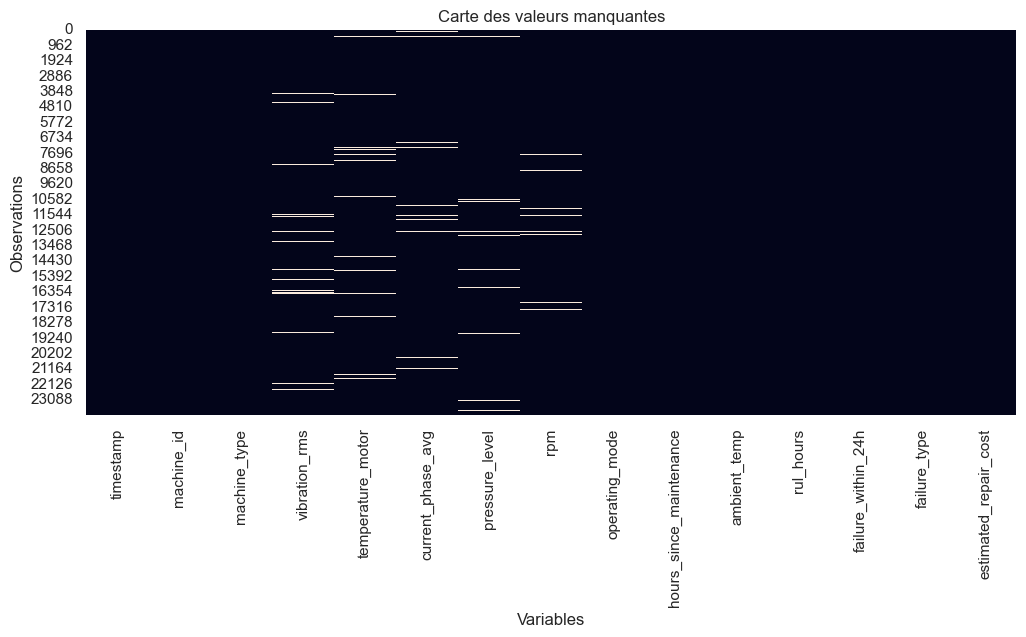

In [89]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Carte des valeurs manquantes")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

In [90]:
print("Nombre de doublons:", df.duplicated().sum())
print("Nombre de timestamps invalides:", df["timestamp"].isna().sum())

Nombre de doublons: 0
Nombre de timestamps invalides: 0


In [100]:
df.isnull().sum()

timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_within_24h            0
failure_type                  0
estimated_repair_cost         0
dtype: int64

### Choix d'imputation

Les valeurs manquantes concernent uniquement des capteurs numériques:
- `vibration_rms`,
- `temperature_motor`,
- `current_phase_avg`,
- `pressure_level`,
- `rpm`.

Pour éviter de créer des valeurs physiquement absurdes, on ne remplace pas par `0`.  
On utilise une **médiane groupée par `machine_type` et `operating_mode`**, puis une médiane globale en fallback si un groupe est enti?rement manquant.

On ajoute aussi des variables `_was_missing`, car le fait qu'un capteur soit manquant peut etre informatif pour la maintenance.

## 4. Nettoyage et imputation

In [91]:
sensor_cols = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
]

df_clean = df.copy()

for col in sensor_cols:
    df_clean[f"{col}_was_missing"] = df_clean[col].isna().astype(int)
    df_clean[col] = df_clean.groupby(["machine_type", "operating_mode"])[col].transform(
        lambda series: series.fillna(series.median())
    )
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

missing_after_cleaning = df_clean.isna().sum().sort_values(ascending=False)
missing_after_cleaning[missing_after_cleaning > 0]

Series([], dtype: int64)

## 5. Analyse de la cible principale: `failure_within_24h`

In [92]:
target_counts = df_clean["failure_within_24h"].value_counts().sort_index()
target_rates = (df_clean["failure_within_24h"].value_counts(normalize=True).sort_index() * 100).round(2)

pd.DataFrame({
    "count": target_counts,
    "percent": target_rates,
})

,count,percent
failure_within_24h,,
0,20482,85.19
1,3560,14.81


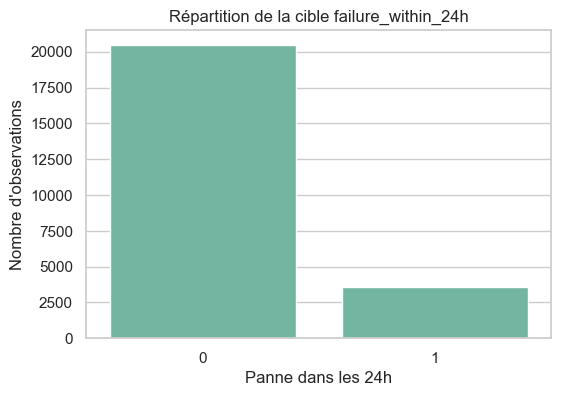

In [93]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="failure_within_24h")
plt.title("Répartition de la cible failure_within_24h")
plt.xlabel("Panne dans les 24h")
plt.ylabel("Nombre d'observations")
plt.show()

La cible est déséquilibrée: les observations sans panne sont majoritaires.  
Pour la modélisation, l'accuracy seule ne suffit pas. Il faut comparer au minimum:
- recall,
- precision,
- F1-score,
- ROC AUC,
- average precision.

Dans un contexte maintenance, le **recall** est particuliérement important, car rater une panne peut coéter cher.

## 6. Analyse des types de panne

In [94]:
failure_type_counts = df_clean["failure_type"].value_counts()
failure_type_counts

failure_type
none              20482
bearing            1117
motor_overheat     1060
hydraulic           728
electrical          655
Name: count, dtype: int64

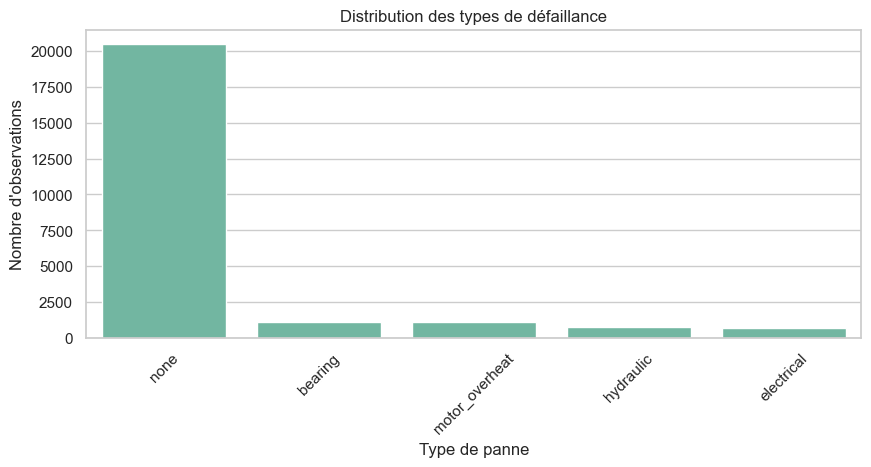

In [95]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df_clean, x="failure_type", order=failure_type_counts.index)
plt.title("Distribution des types de défaillance")
plt.xlabel("Type de panne")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=45)
plt.show()

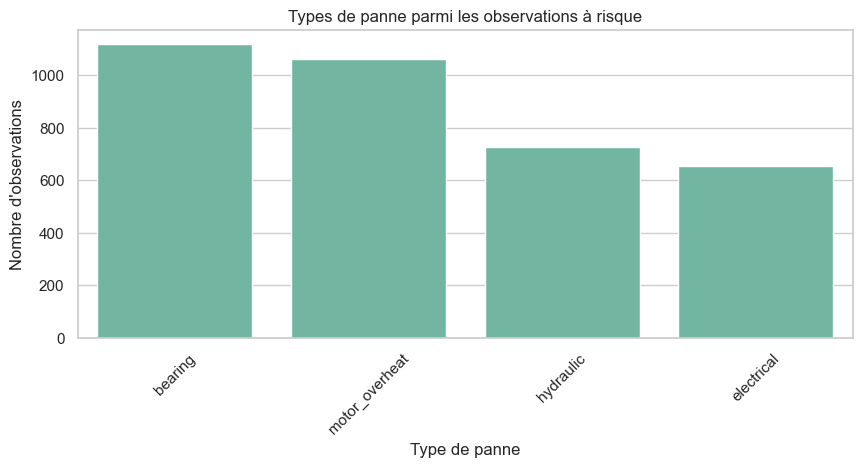

In [96]:
failures_only = df_clean[df_clean["failure_within_24h"] == 1]

plt.figure(figsize=(10, 4))
sns.countplot(
    data=failures_only,
    x="failure_type",
    order=failures_only["failure_type"].value_counts().index,
)
plt.title("Types de panne parmi les observations à risque")
plt.xlabel("Type de panne")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=45)
plt.show()

## 7. Analyse des variables num?riques

In [97]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

continuous_cols = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "hours_since_maintenance",
    "ambient_temp",
    "rul_hours",
    "estimated_repair_cost",
]

df_clean[continuous_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
vibration_rms,24042.0,1.617967,1.073208,0.35,0.8200,1.25,2.2700,10.00
temperature_motor,24042.0,51.378509,12.458087,28.00,42.6525,49.99,59.8775,95.00
current_phase_avg,24042.0,8.814323,5.356708,2.20,4.6300,6.44,13.1400,35.00
pressure_level,24042.0,58.968742,38.653471,10.10,22.8000,46.10,95.0000,206.50
rpm,24042.0,1144.554268,911.945149,124.10,490.3500,856.40,1677.1000,4098.80
hours_since_maintenance,24042.0,172.630624,150.722469,0.00,42.8700,121.61,295.5750,575.63
ambient_temp,24042.0,12.996398,2.883994,8.00,10.5000,13.00,15.5000,18.00
rul_hours,24042.0,27.812510,26.393801,0.50,0.5000,22.57,46.4100,98.34
estimated_repair_cost,24042.0,608.870144,1566.793887,0.00,0.0000,0.00,0.0000,7995.00


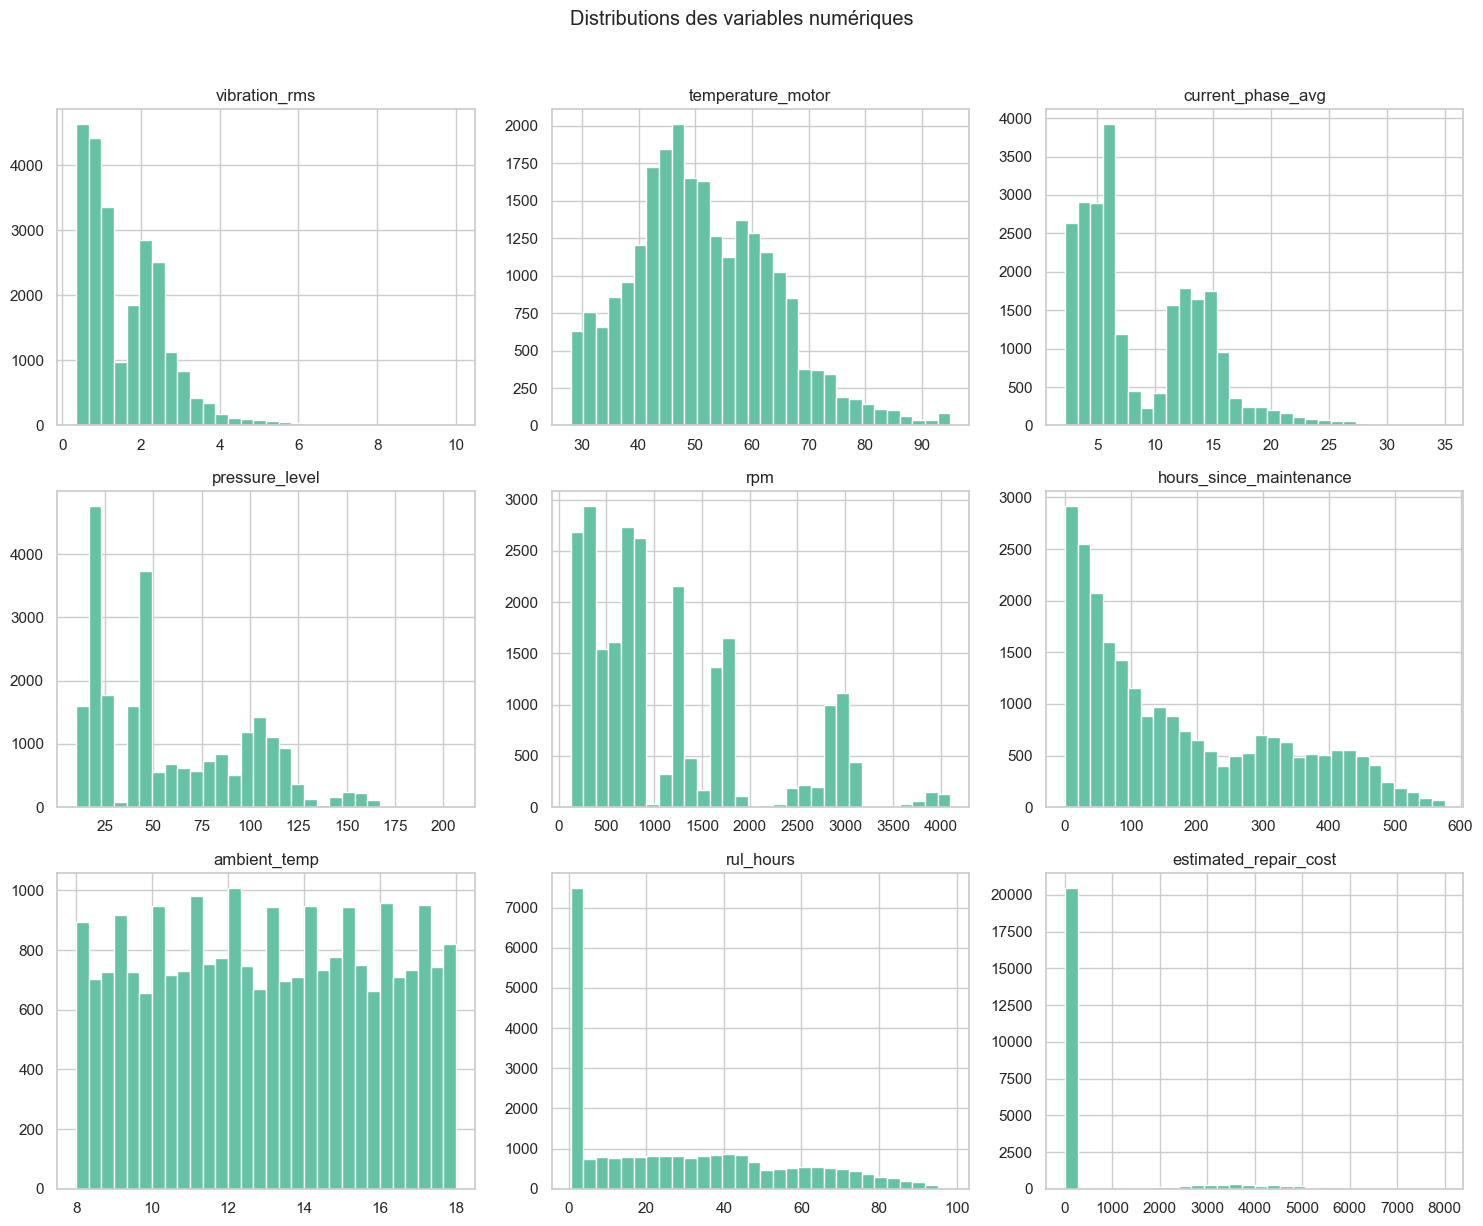

In [98]:
df_clean[continuous_cols].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distributions des variables numériques", y=1.02)
plt.tight_layout()
plt.show()

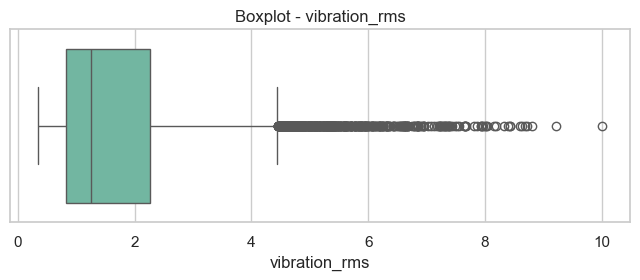

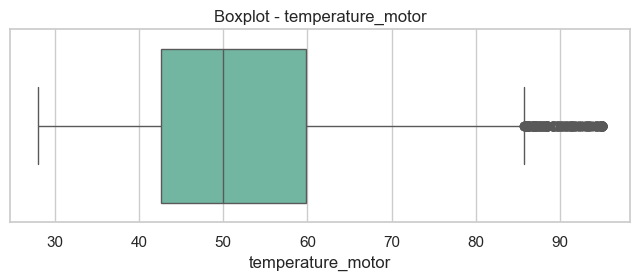

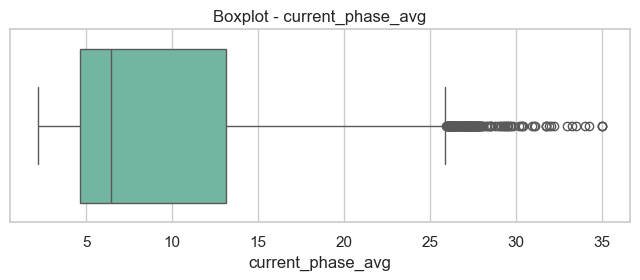

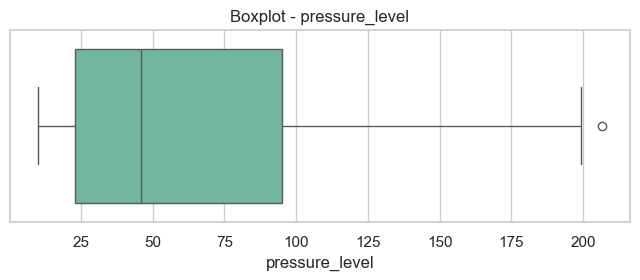

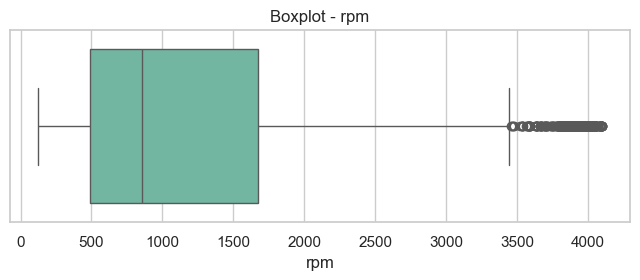

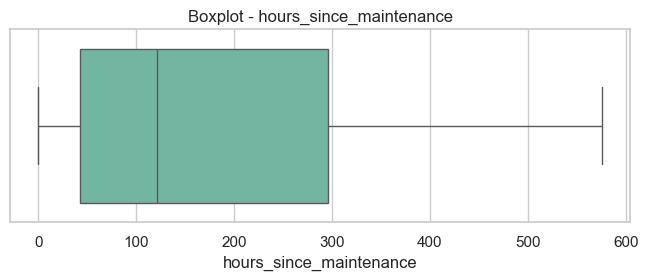

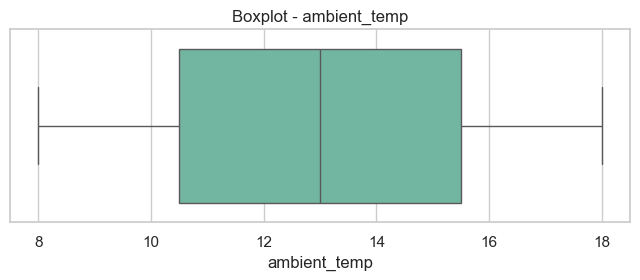

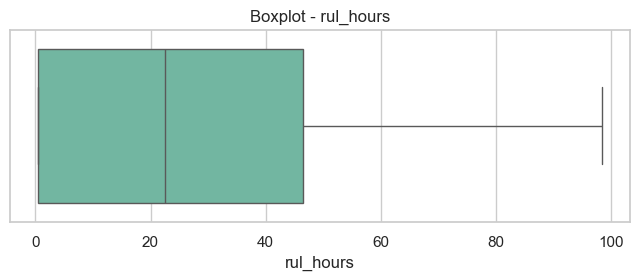

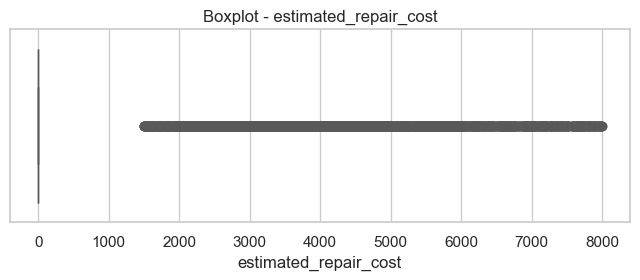

In [99]:
for col in continuous_cols:
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(data=df_clean, x=col)
    plt.title(f"Boxplot - {col}")
    plt.show()

## 8. Comparaison panne vs pas panne

In [17]:
comparison_cols = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "hours_since_maintenance",
    "ambient_temp",
    "rul_hours",
]

summary_by_target = df_clean.groupby("failure_within_24h")[comparison_cols].agg(["mean", "median", "std"]).T
summary_by_target

failure_within_24h                        0            1
vibration_rms           mean       1.503662     2.275604
                        median     1.150000     1.935000
                        std        0.905415     1.598391
temperature_motor       mean      49.433522    62.568743
                        median    48.260000    61.555000
                        std       11.174151    13.521497
current_phase_avg       mean       8.474589    10.768938
                        median     6.145000     7.810000
                        std        5.043458     6.554734
pressure_level          mean      58.731608    60.333062
                        median    46.000000    46.900000
                        std       38.542816    39.261726
rpm                     mean    1152.984586  1096.051517
                        median   861.800000   801.600000
                        std      918.737281   870.379260
hours_since_maintenance mean     166.377279   208.608438
                        median   114.260000   152.500000
                        std      145.518016   173.425100
ambient_temp            mean      12.991700    13.023427
                        median    13.000000    13.000000
                        std        2.884353     2.882184
rul_hours               mean      30.598986    11.780882
                        median    29.760000    11.680000
                        std       27.511557     6.951295

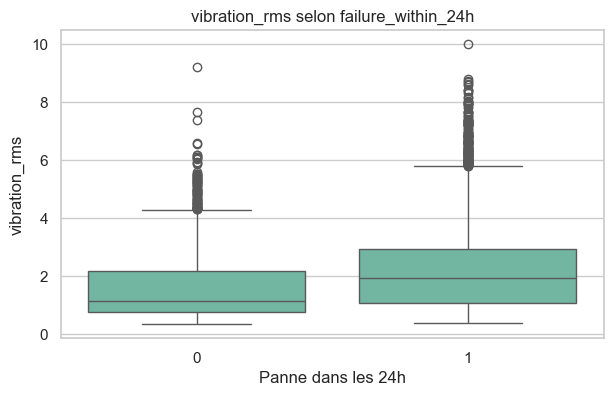

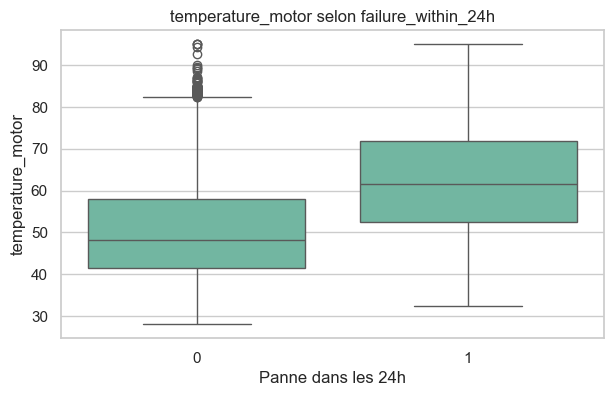

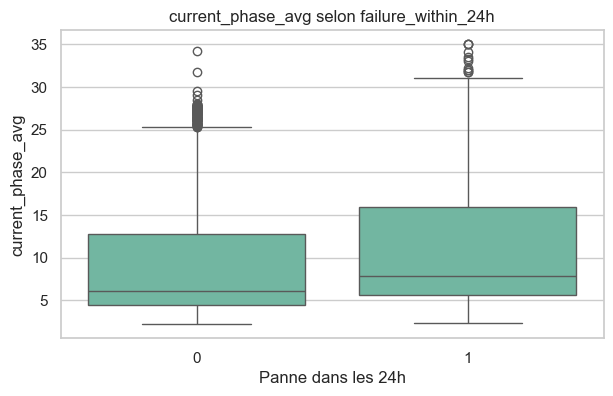

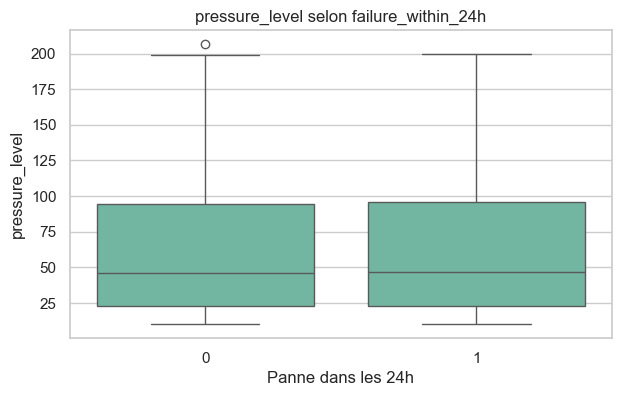

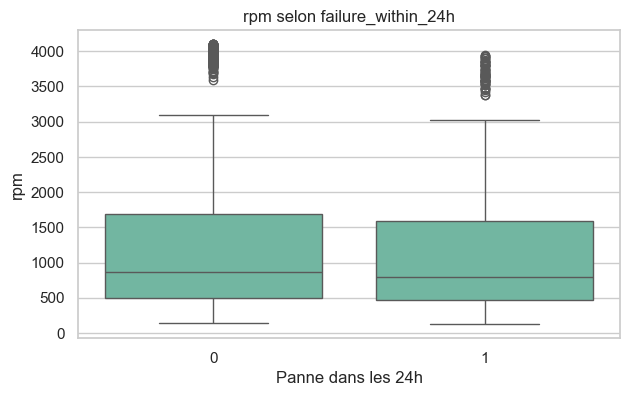

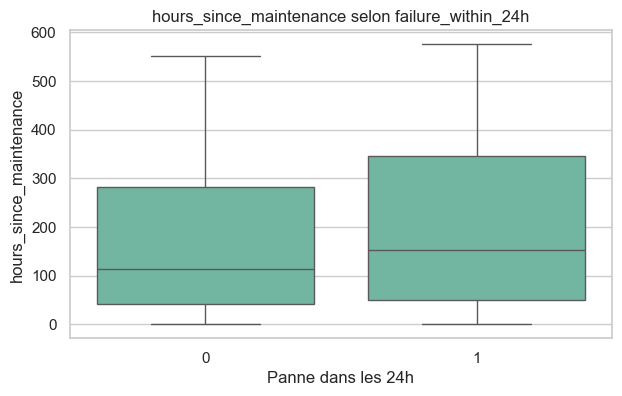

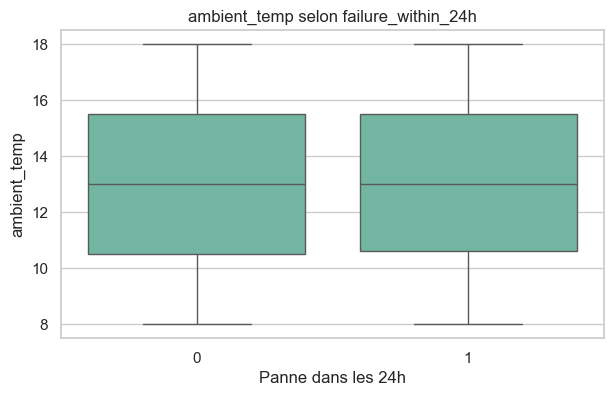

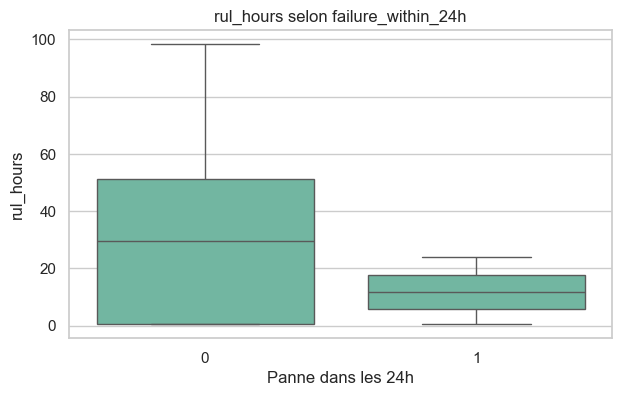

In [18]:
for col in comparison_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_clean, x="failure_within_24h", y=col)
    plt.title(f"{col} selon failure_within_24h")
    plt.xlabel("Panne dans les 24h")
    plt.ylabel(col)
    plt.show()

## 9. Variables catégorielles

,count
machine_type,
Pump,6114
Robotic Arm,6003
Compressor,5988
CNC,5937


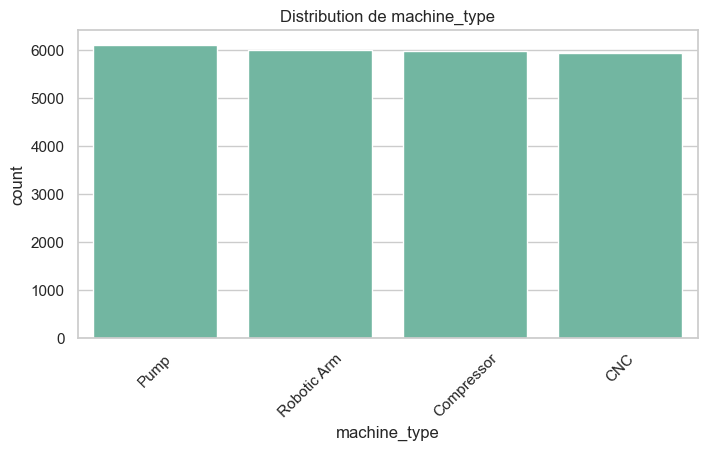

,count
operating_mode,
normal,11632
idle,10862
peak,1548


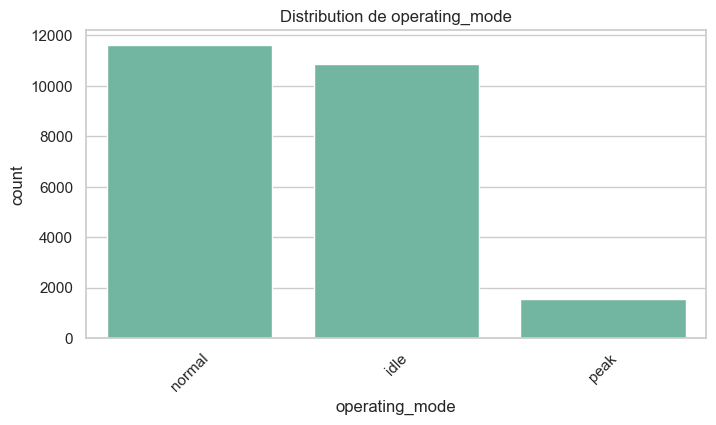

In [19]:
categorical_cols = ["machine_type", "operating_mode"]

for col in categorical_cols:
    display(df_clean[col].value_counts().to_frame("count"))
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_clean, x=col, order=df_clean[col].value_counts().index)
    plt.title(f"Distribution de {col}")
    plt.xticks(rotation=45)
    plt.show()

,failure_rate_percent
machine_type,
Compressor,16.00
Pump,14.93
Robotic Arm,14.24
CNC,14.05


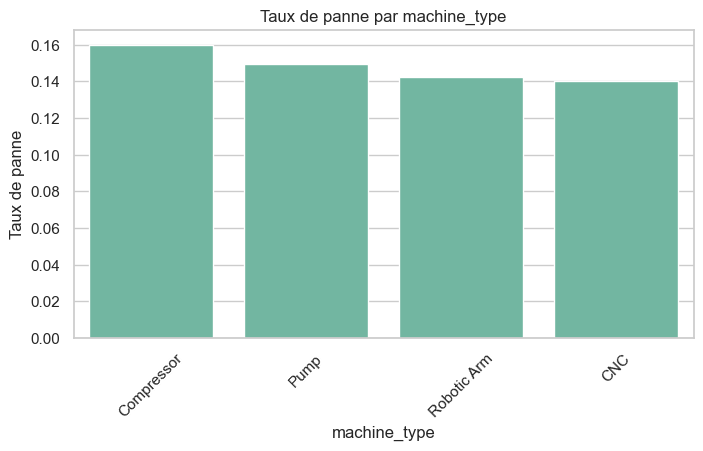

,failure_rate_percent
operating_mode,
peak,16.02
normal,14.94
idle,14.49


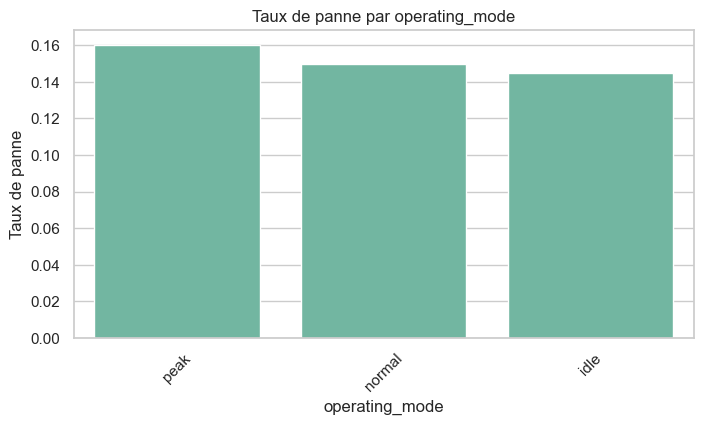

In [20]:
for col in categorical_cols:
    rate = df_clean.groupby(col)["failure_within_24h"].mean().sort_values(ascending=False)
    display((rate * 100).round(2).to_frame("failure_rate_percent"))
    plt.figure(figsize=(8, 4))
    sns.barplot(x=rate.index, y=rate.values)
    plt.title(f"Taux de panne par {col}")
    plt.ylabel("Taux de panne")
    plt.xticks(rotation=45)
    plt.show()

## 10. Analyse temporelle

In [21]:
df_clean["hour"] = df_clean["timestamp"].dt.hour
df_clean["dayofweek"] = df_clean["timestamp"].dt.dayofweek
df_clean["month"] = df_clean["timestamp"].dt.month
df_clean["is_weekend"] = df_clean["dayofweek"].isin([5, 6]).astype(int)

time_features = ["hour", "dayofweek", "month", "is_weekend"]
df_clean[time_features].head()

,hour,dayofweek,month,is_weekend
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


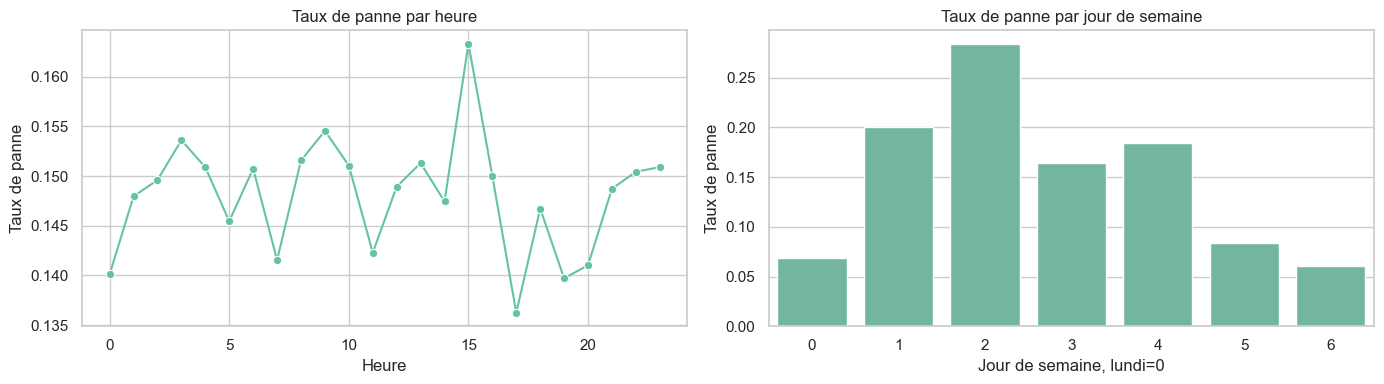

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly_rate = df_clean.groupby("hour")["failure_within_24h"].mean()
sns.lineplot(x=hourly_rate.index, y=hourly_rate.values, marker="o", ax=axes[0])
axes[0].set_title("Taux de panne par heure")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Taux de panne")

day_rate = df_clean.groupby("dayofweek")["failure_within_24h"].mean()
sns.barplot(x=day_rate.index, y=day_rate.values, ax=axes[1])
axes[1].set_title("Taux de panne par jour de semaine")
axes[1].set_xlabel("Jour de semaine, lundi=0")
axes[1].set_ylabel("Taux de panne")

plt.tight_layout()
plt.show()

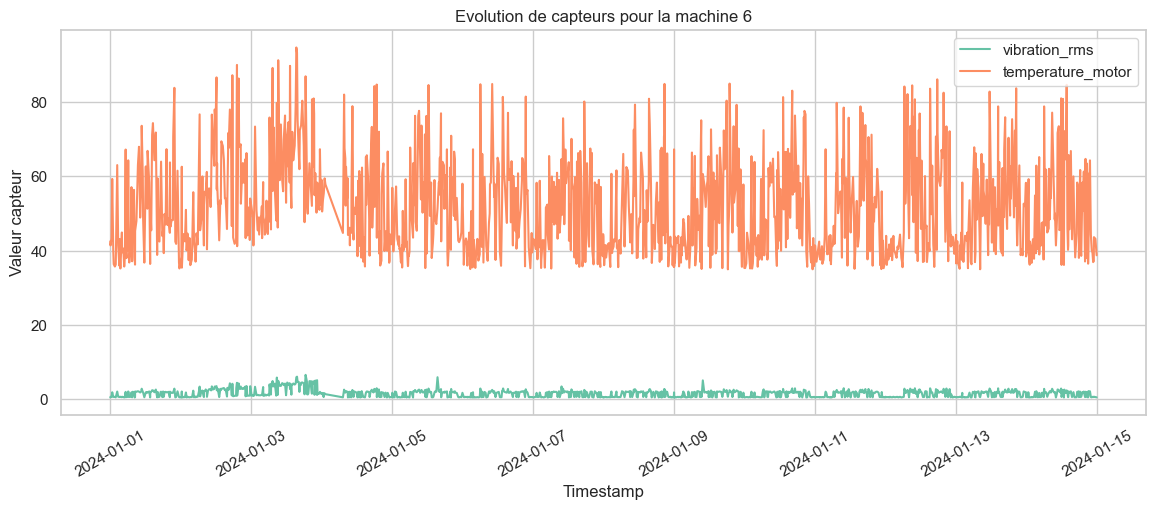

In [23]:
sample_machine = df_clean["machine_id"].value_counts().index[0]
sample_df = df_clean[df_clean["machine_id"] == sample_machine].sort_values("timestamp")

plt.figure(figsize=(14, 5))
sns.lineplot(data=sample_df, x="timestamp", y="vibration_rms", label="vibration_rms")
sns.lineplot(data=sample_df, x="timestamp", y="temperature_motor", label="temperature_motor")
plt.title(f"Evolution de capteurs pour la machine {sample_machine}")
plt.xlabel("Timestamp")
plt.ylabel("Valeur capteur")
plt.xticks(rotation=30)
plt.show()

## 11. Corrélations

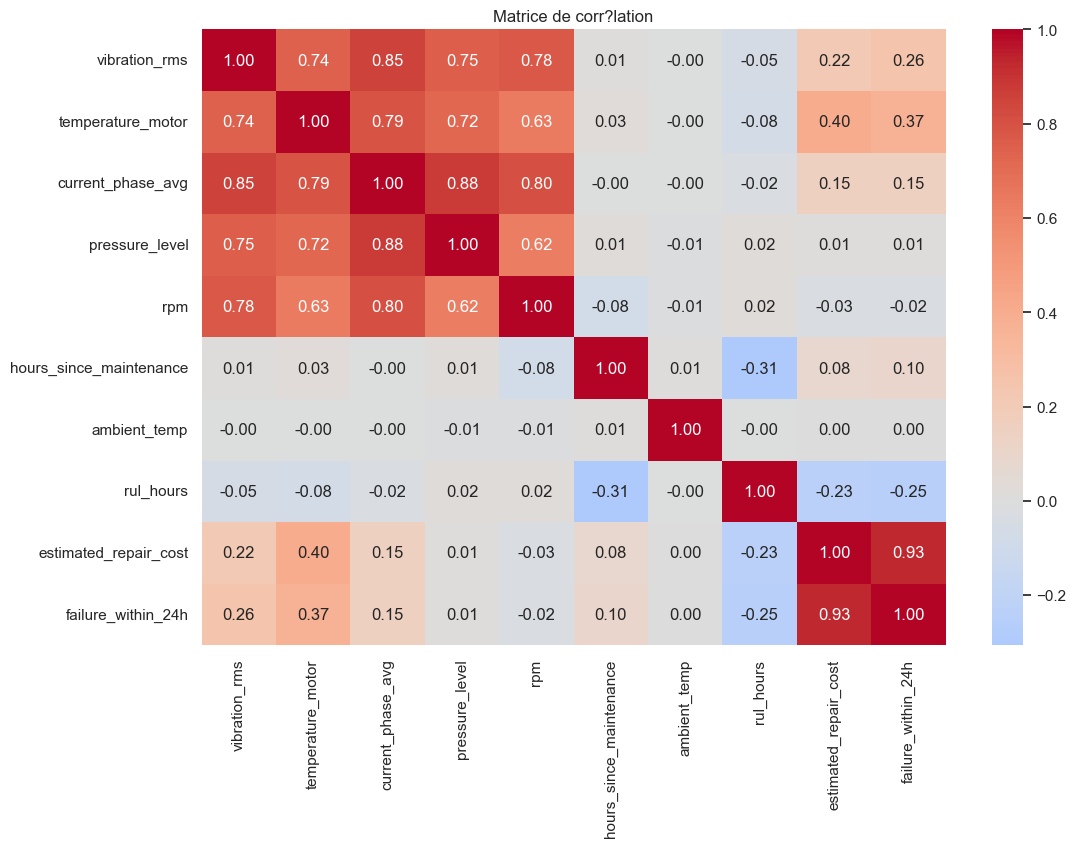

In [24]:
corr_cols = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "hours_since_maintenance",
    "ambient_temp",
    "rul_hours",
    "estimated_repair_cost",
    "failure_within_24h",
]

corr = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corr?lation")
plt.show()

## 12. Health Score

Le cahier des charges propose de cr?er un score de sant? machine.  
On applique la formule suivante apr?s normalisation MinMax:

`health_score = 1 - (0.30*vibration + 0.25*temperature + 0.20*pressure + 0.15*rpm + 0.10*anomaly_trend)`

Interpr?tation:
- `1`: machine en excellente sant?,
- `0`: machine critique.

In [25]:
df_clean = df_clean.sort_values(["machine_id", "timestamp"]).copy()

trend_base_cols = ["vibration_rms", "temperature_motor", "pressure_level", "rpm"]
for col in trend_base_cols:
    df_clean[f"{col}_diff_1"] = df_clean.groupby("machine_id")[col].diff().fillna(0)

trend_cols = [f"{col}_diff_1" for col in trend_base_cols]
df_clean["anomaly_trend"] = df_clean[trend_cols].abs().mean(axis=1)

health_input_cols = ["vibration_rms", "temperature_motor", "pressure_level", "rpm", "anomaly_trend"]
scaler = MinMaxScaler()
health_norm = pd.DataFrame(
    scaler.fit_transform(df_clean[health_input_cols]),
    columns=[f"{col}_norm" for col in health_input_cols],
    index=df_clean.index,
)

df_clean = pd.concat([df_clean, health_norm], axis=1)

df_clean["health_score"] = 1 - (
    0.30 * df_clean["vibration_rms_norm"]
    + 0.25 * df_clean["temperature_motor_norm"]
    + 0.20 * df_clean["pressure_level_norm"]
    + 0.15 * df_clean["rpm_norm"]
    + 0.10 * df_clean["anomaly_trend_norm"]
)

df_clean["health_score"] = df_clean["health_score"].clip(0, 1)

df_clean[["health_score", "failure_within_24h"]].describe()

,health_score,failure_within_24h
count,24042.000000,24042.000000
mean,0.771303,0.148074
std,0.141996,0.355181
min,0.206799,0.000000
25%,0.653156,0.000000
50%,0.811351,0.000000
75%,0.885393,0.000000
max,0.992690,1.000000


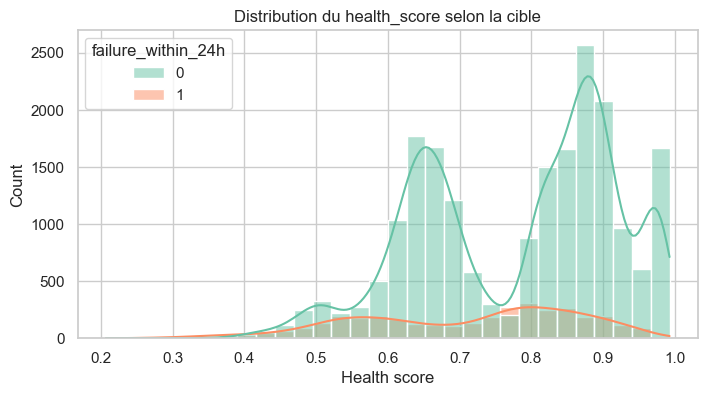

In [26]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df_clean, x="health_score", hue="failure_within_24h", bins=30, kde=True)
plt.title("Distribution du health_score selon la cible")
plt.xlabel("Health score")
plt.show()

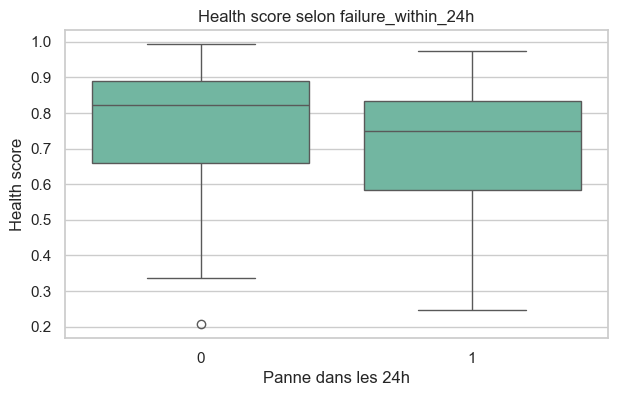

In [27]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="failure_within_24h", y="health_score")
plt.title("Health score selon failure_within_24h")
plt.xlabel("Panne dans les 24h")
plt.ylabel("Health score")
plt.show()

## 13. Pr?paration pour la mod?lisation

Pour la t?che principale `failure_within_24h`, certaines colonnes ne doivent pas ?tre utilis?es comme features car elles peuvent cr?er une fuite de donn?es:
- `failure_type`: connu apr?s la panne,
- `rul_hours`: dur?e de vie restante directement li?e ? la panne,
- `estimated_repair_cost`: co?t connu ou estim? apr?s diagnostic.

Ces variables peuvent ?tre analys?es, mais elles sont exclues des features du mod?le de classification binaire.

In [28]:
target = "failure_within_24h"
leakage_cols = ["failure_type", "rul_hours", "estimated_repair_cost"]
non_feature_cols = ["timestamp", target] + leakage_cols

feature_cols = [col for col in df_clean.columns if col not in non_feature_cols]

X = df_clean[feature_cols].copy()
y = df_clean[target].copy()

print(f"Nombre de features utilis?es: {len(feature_cols)}")
feature_cols

Nombre de features utilis?es: 30


['machine_id',
 'machine_type',
 'vibration_rms',
 'temperature_motor',
 'current_phase_avg',
 'pressure_level',
 'rpm',
 'operating_mode',
 'hours_since_maintenance',
 'ambient_temp',
 'vibration_rms_was_missing',
 'temperature_motor_was_missing',
 'current_phase_avg_was_missing',
 'pressure_level_was_missing',
 'rpm_was_missing',
 'hour',
 'dayofweek',
 'month',
 'is_weekend',
 'vibration_rms_diff_1',
 'temperature_motor_diff_1',
 'pressure_level_diff_1',
 'rpm_diff_1',
 'anomaly_trend',
 'vibration_rms_norm',
 'temperature_motor_norm',
 'pressure_level_norm',
 'rpm_norm',
 'anomaly_trend_norm',
 'health_score']

## 14. Split train/test chronologique

In [29]:
df_model = df_clean.sort_values("timestamp").copy()
split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]
X_test = test_df[feature_cols]
y_test = test_df[target]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("P?riode train:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("P?riode test:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Taux de panne train:", round(y_train.mean(), 4))
print("Taux de panne test:", round(y_test.mean(), 4))

Train: (19233, 30) Test: (4809, 30)
P?riode train: 2024-01-01 00:00:00 -> 2024-01-12 05:49:36
P?riode test: 2024-01-12 05:49:38 -> 2024-01-14 23:59:38
Taux de panne train: 0.1695
Taux de panne test: 0.0624


## 15. Pipeline de preprocessing

In [30]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)
print("NaN apr?s preprocessing train:", np.isnan(X_train_processed).sum())
print("NaN apr?s preprocessing test:", np.isnan(X_test_processed).sum())

X_train_processed: (19233, 35)
X_test_processed: (4809, 35)
NaN apr?s preprocessing train: 0
NaN apr?s preprocessing test: 0


## 16. Sauvegarde du dataset nettoy?

On sauvegarde `df_clean`, qui contient:
- les valeurs manquantes imput?es,
- les indicateurs `_was_missing`,
- les features temporelles,
- les variables de tendance,
- le `health_score`.

In [31]:
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Dataset nettoy? sauvegard? dans: {PROCESSED_DATA_PATH}")
print("Shape:", df_clean.shape)
print("Nombre total de NaN:", int(df_clean.isna().sum().sum()))

Dataset nettoy? sauvegard? dans: C:\Users\chaim\MonDossier\EFREI\2025-2026\Projet Data Science\projet_data_science_M1_EFREI\data\processed\cleaned_data.csv
Shape: (24042, 35)
Nombre total de NaN: 0


## 17. Conclusion EDA

Points importants observ?s:
- La cible `failure_within_24h` est d?s?quilibr?e.
- Les valeurs manquantes concernent uniquement les capteurs et sont trait?es par m?diane group?e.
- Les variables temporelles et les tendances capteurs enrichissent le dataset.
- `failure_type`, `rul_hours` et `estimated_repair_cost` sont utiles pour l'analyse, mais doivent ?tre exclues de la classification binaire pour ?viter la fuite de donn?es.
- Le `health_score` fournit un indicateur m?tier interpr?table pour le dashboard.

Suite du projet:
- entra?ner au moins 4 mod?les,
- inclure au moins un mod?le Deep Learning,
- comparer les performances quantitativement,
- interpr?ter les features importantes,
- exposer les r?sultats dans un dashboard interactif.